# Graded Response Model — TMA (Single Scale)

Fits a single-dimensional GRM to all 50 TMA items. With binary responses (K=2), this is equivalent to a 2PL IRT model.

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ['JAX_PLATFORMS'] = 'cpu'

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

## 1. Load Data

In [2]:
from bayesianquilts.data.tma import get_data, item_keys, response_cardinality

df, num_people = get_data(polars_out=True)
print(f"Dataset shape: {df.shape}")
print(f"Number of people: {num_people}")
print(f"Number of items: {len(item_keys)}")
print(f"Response cardinality: {response_cardinality} (binary: 0=False, 1=True)")
df.head()

Dataset shape: (5410, 51)
Number of people: 5410
Number of items: 50
Response cardinality: 2 (binary: 0=False, 1=True)


person,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28,Q29,Q30,Q31,Q32,Q33,Q34,Q35,Q36,Q37,Q38,Q39,Q40,Q41,Q42,Q43,Q44,Q45,Q46,Q47,Q48,Q49,Q50
u32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,1,1,1,0,1,0,1,1,0,1,0,0,1,1,1,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,1
1,0,1,0,0,1,0,0,1,0,1,0,0,1,1,1,1,0,0,1,1,1,1,0,0,0,0,1,0,0,1,1,0,1,1,0,1,0,1,1,1,0,0,1,1,1,1,1,1,1,1
2,1,0,0,1,0,0,0,0,0,0,0,1,0,1,0,1,0,1,1,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,1
3,0,1,1,0,0,0,0,1,1,1,0,1,1,1,0,0,1,0,1,0,1,0,0,1,0,0,0,0,1,1,1,1,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1
4,0,1,1,0,0,1,0,0,0,0,0,1,1,1,0,0,0,1,1,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1


In [3]:
SUBSAMPLE_N = num_people
sub_df = df
print(f"Using full dataset: N = {SUBSAMPLE_N}")

Using full dataset: N = 5410


## 2. Prepare Data

In [4]:
def make_data_dict(dataframe):
    data = {}
    for col in dataframe.columns:
        arr = dataframe[col].to_numpy().astype(np.float64)
        data[col] = arr
    data['person'] = np.arange(len(dataframe), dtype=np.float64)
    return data

batch = make_data_dict(sub_df)

# Check for missing/invalid values
n_bad = sum(
    np.sum(np.isnan(batch[k]) | (batch[k] < 0) | (batch[k] >= response_cardinality))
    for k in item_keys
)
print(f"Bad/missing values: {n_bad}")

BATCH_SIZE = 256
steps_per_epoch = int(np.ceil(SUBSAMPLE_N / BATCH_SIZE))
print(f"N: {SUBSAMPLE_N}, Batch size: {BATCH_SIZE}, Steps per epoch: {steps_per_epoch}")

def data_factory():
    indices = np.arange(SUBSAMPLE_N)
    np.random.shuffle(indices)
    for start in range(0, SUBSAMPLE_N, BATCH_SIZE):
        end = min(start + BATCH_SIZE, SUBSAMPLE_N)
        idx_batch = indices[start:end]
        yield {k: v[idx_batch] for k, v in batch.items()}

Bad/missing values: 2612
N: 5410, Batch size: 256, Steps per epoch: 22


## 3. Fit Baseline GRM (Ignorable Missingness)

In [5]:
from bayesianquilts.irt.grm import GRModel

model_baseline = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    kappa_scale=0.1,
    response_cardinality=response_cardinality,
    dtype=jnp.float64,
)

NUM_EPOCHS = 200

losses_baseline, params_baseline = model_baseline.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    patience=10,
    zero_nan_grads=True,
)

print(f"Baseline final loss: {losses_baseline[-1]:.2f}")

--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.5
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'eta\\softplus\\normal\\loc', 'eta\\softplus\\normal\\scale', 'kappa\\softplus\\igamma\\concentration', 'kappa\\softplus\\igamma\\scale', 'kappa_a\\softplus\\igamma\\concentration', 'kappa_a\\softplus\\igamma\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/22 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/22 [00:03<?, ?batch/s, best_loss=inf, loss=9977.8300]

Epoch 1/200 (LR: 0.000200):   5%|▍         | 1/22 [00:03<01:19,  3.79s/batch, best_loss=inf, loss=9977.8300]

Epoch 1/200 (LR: 0.000200):   5%|▍         | 1/22 [00:03<01:19,  3.79s/batch, best_loss=inf, loss=9972.4309]

...

Epoch 200/200 (LR: 0.000200):  55%|█████▍    | 12/22 [00:00<00:00, 119.06batch/s, best_loss=7544.4816, loss=7860.8982]

Epoch 200/200 (LR: 0.000200):  55%|█████▍    | 12/22 [00:00<00:00, 119.06batch/s, best_loss=7544.4816, loss=7968.5353]

Epoch 200/200 (LR: 0.000200):  55%|█████▍    | 12/22 [00:00<00:00, 119.06batch/s, best_loss=7544.4816, loss=1215.7638]

  -> New best loss found. Checkpoint saved.                    

--- Training Finished ---


Baseline final loss: 7540.39


In [6]:
model_baseline.save_to_disk('grm_baseline')

## 4. Fit MICEBayesianLOO Imputation Model

In [7]:
from bayesianquilts.imputation.mice_loo import MICEBayesianLOO

# Convert to pandas with NaN for missing values (-1 marks missing in TMA)
imputation_df = sub_df.select(item_keys).to_pandas()
imputation_df = imputation_df.replace(-1, np.nan)
print(f"Imputation DataFrame shape: {imputation_df.shape}")
print(f"NaN count: {imputation_df.isna().sum().sum()}")

mice_loo = MICEBayesianLOO(
    random_state=42,
    prior_scale=1.0,
    pathfinder_num_samples=100,
    pathfinder_maxiter=50,
    batch_size=512,
    verbose=True,
)

mice_loo.fit_loo_models(
    X_df=imputation_df,
    n_top_features=50,
    n_jobs=-1,
    fit_zero_predictors=True,
    seed=42,
)

print(f"\nFitted variable names: {mice_loo.variable_names[:5]}...")
print(f"Zero-predictor models: {len(mice_loo.zero_predictor_results)}")
print(f"Univariate models: {len(mice_loo.univariate_results)}")

Imputation DataFrame shape: (5410, 50)
NaN count: 2612
Computing feature correlations...


Fitting MICE Bayesian LOO-CV models with Pathfinder
  Variables: 50
  Observations: 5410
  Min obs per model: 5
  Parallel jobs: -1
  Top features per target: 50

Fitting zero-predictor models...
  Scheduling 50 zero-predictor jobs...


  Var 0 (Q1): n_obs=5379, elpd/n=-0.0643


  Var 1 (Q2): n_obs=5368, elpd/n=-0.0644


  Var 2 (Q3): n_obs=5378, elpd/n=-0.0578


...

  Processing Q47 (49 valid predictors)


  Processing Q48 (49 valid predictors)


  Processing Q49 (49 valid predictors)


  Processing Q50 (49 valid predictors)



Fitted variable names: ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']...
Zero-predictor models: 50
Univariate models: 2450


In [8]:
mice_loo.save('mice_loo_model.yaml')

## 5. Fit GRM with Analytic Rao-Blackwellized Imputation

In [9]:
model_imputed = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    kappa_scale=0.1,
    response_cardinality=response_cardinality,
    dtype=jnp.float64,
    imputation_model=mice_loo,
)

model_imputed.validate_imputation_model()
print("Imputation model validation passed.")

losses_imputed, params_imputed = model_imputed.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    patience=10,
    zero_nan_grads=True,
)

print(f"Imputed final loss: {losses_imputed[-1]:.2f}")

/home/josh/workspace/bayesianquilts/python/bayesianquilts/irt/irt.py:220: UserWarning: Items with high PSIS khat (>= 0.7), imputation may be unreliable: ['Q25']
  warnings.warn(


Imputation model validation passed.
--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.5
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'eta\\softplus\\normal\\loc', 'eta\\softplus\\normal\\scale', 'kappa\\softplus\\igamma\\concentration', 'kappa\\softplus\\igamma\\scale', 'kappa_a\\softplus\\igamma\\concentration', 'kappa_a\\softplus\\igamma\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/22 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/22 [00:03<?, ?batch/s, best_loss=inf, loss=9977.0695]

Epoch 1/200 (LR: 0.000200):   5%|▍         | 1/22 [00:03<01:21,  3.87s/batch, best_loss=inf, loss=9977.0695]

...

Epoch 200/200 (LR: 0.000200):  82%|████████▏ | 18/22 [00:00<00:00, 26.52batch/s, best_loss=7592.4381, loss=7997.5891]

Epoch 200/200 (LR: 0.000200):  82%|████████▏ | 18/22 [00:00<00:00, 26.52batch/s, best_loss=7592.4381, loss=7945.3855]

Epoch 200/200 (LR: 0.000200):  95%|█████████▌| 21/22 [00:00<00:00, 27.33batch/s, best_loss=7592.4381, loss=7945.3855]

Epoch 200/200 (LR: 0.000200):  95%|█████████▌| 21/22 [00:00<00:00, 27.33batch/s, best_loss=7592.4381, loss=1160.9918]

  -> New best loss found. Checkpoint saved.                    

--- Training Finished ---
Imputed final loss: 7587.52


In [10]:
model_imputed.save_to_disk('grm_imputed')

## 6. Compare Results

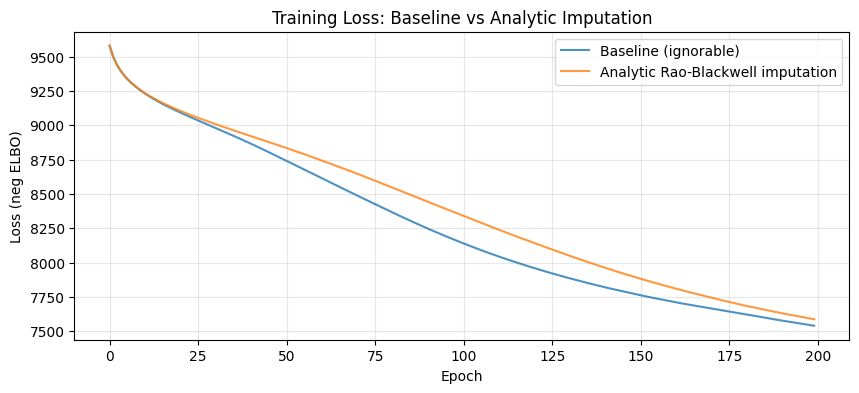

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(losses_baseline, label='Baseline (ignorable)', alpha=0.8)
plt.plot(losses_imputed, label='Analytic Rao-Blackwell imputation', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('Loss (neg ELBO)')
plt.title('Training Loss: Baseline vs Analytic Imputation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
def calibrate_manually(model, n_samples=32, seed=42):
    surrogate = model.surrogate_distribution_generator(model.params)
    key = jax.random.PRNGKey(seed)
    samples = surrogate.sample(n_samples, seed=key)
    expectations = {k: jnp.mean(v, axis=0) for k, v in samples.items()}
    model.calibrated_expectations = expectations
    model.surrogate_sample = samples

calibrate_manually(model_baseline, n_samples=32, seed=101)
calibrate_manually(model_imputed, n_samples=32, seed=102)

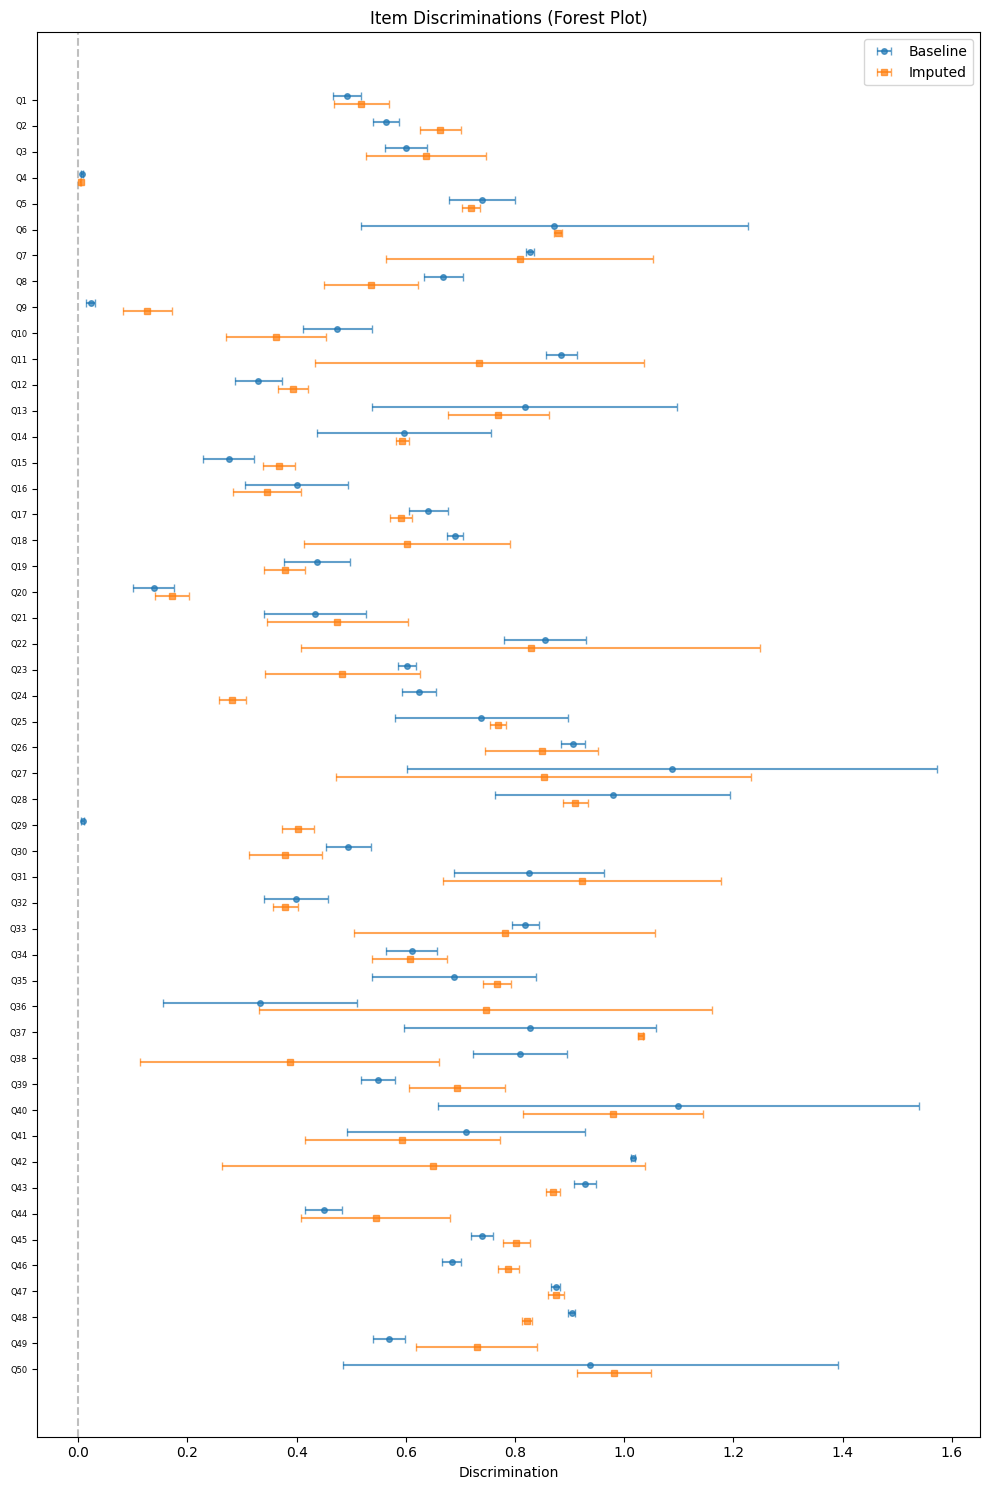

In [13]:
# Forest plot of discriminations with uncertainty
disc_samples_base = np.array(model_baseline.surrogate_sample['discriminations']).reshape(
    -1, len(item_keys))
disc_samples_imp = np.array(model_imputed.surrogate_sample['discriminations']).reshape(
    -1, len(item_keys))

disc_mean_base = disc_samples_base.mean(axis=0)
disc_std_base = disc_samples_base.std(axis=0)
disc_mean_imp = disc_samples_imp.mean(axis=0)
disc_std_imp = disc_samples_imp.std(axis=0)

fig, ax = plt.subplots(figsize=(10, max(7, len(item_keys) * 0.3)))
y_pos = np.arange(len(item_keys))
offset = 0.15

ax.errorbar(disc_mean_base, y_pos - offset, xerr=disc_std_base, fmt='o',
            capsize=3, markersize=4, elinewidth=1.5, color='tab:blue',
            ecolor='tab:blue', alpha=0.7, label='Baseline')
ax.errorbar(disc_mean_imp, y_pos + offset, xerr=disc_std_imp, fmt='s',
            capsize=3, markersize=4, elinewidth=1.5, color='tab:orange',
            ecolor='tab:orange', alpha=0.7, label='Imputed')

ax.set_yticks(y_pos)
ax.set_yticklabels(item_keys, fontsize=6)
ax.set_xlabel('Discrimination')
ax.set_title('Item Discriminations (Forest Plot)')
ax.legend()
ax.invert_yaxis()
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
ab_base = np.array(model_baseline.calibrated_expectations['abilities']).flatten()
ab_imp = np.array(model_imputed.calibrated_expectations['abilities']).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(ab_base, ab_imp, alpha=0.3, s=10, edgecolors='none')
lims = [min(ab_base.min(), ab_imp.min()), max(ab_base.max(), ab_imp.max())]
ax.plot(lims, lims, 'k--', alpha=0.5, label='y = x')
ax.set_xlabel('Baseline Ability')
ax.set_ylabel('Imputed Ability')
ax.set_title('Ability Estimates: Baseline vs Imputed')
ax.legend()
ax.set_aspect('equal')

ax = axes[1]
ax.hist(ab_base, bins=30, histtype='step', linewidth=2, label='Baseline', color='tab:blue')
ax.hist(ab_imp, bins=30, histtype='step', linewidth=2, label='Imputed', color='tab:orange')
ax.set_xlabel('Ability (TMA latent trait)')
ax.set_ylabel('Count')
ax.set_title('Ability Distribution')
ax.legend()

plt.tight_layout()
plt.show()

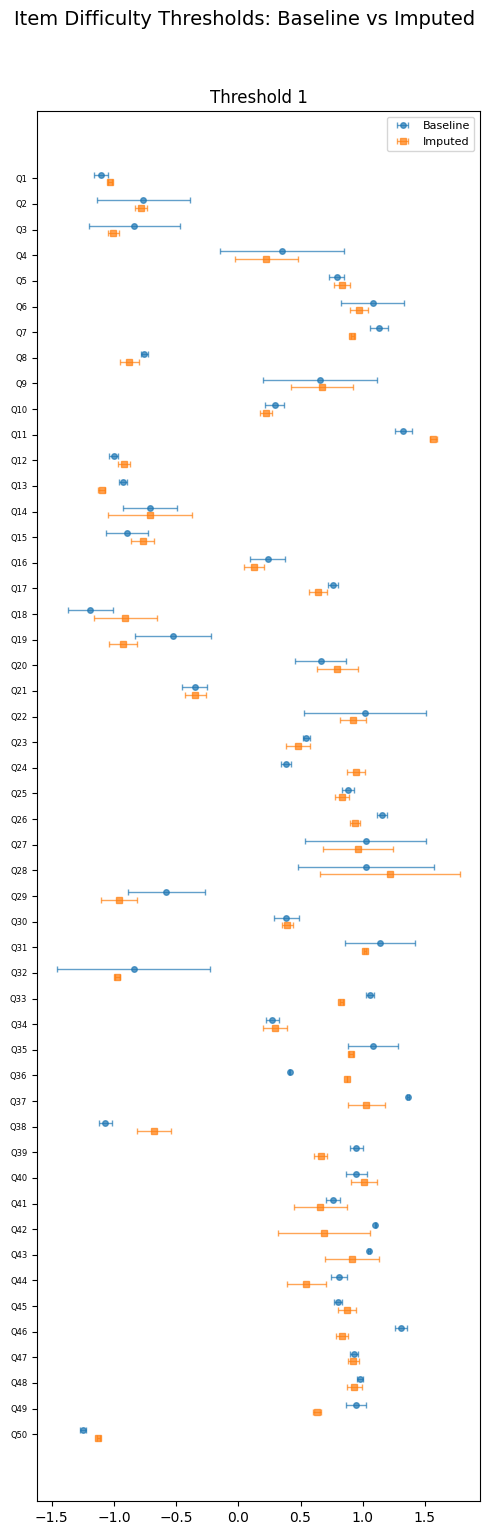

In [15]:
# Difficulty threshold comparison
def compute_thresholds(model):
    diff0 = np.array(model.surrogate_sample['difficulties0'])
    ddiff = np.array(model.surrogate_sample['ddifficulties'])
    d0 = np.concatenate([diff0, ddiff], axis=-1)
    thresholds = np.cumsum(d0, axis=-1)
    n_samples = thresholds.shape[0]
    n_thresholds = thresholds.size // (n_samples * len(item_keys))
    return thresholds.reshape(n_samples, len(item_keys), n_thresholds)

thresh_base = compute_thresholds(model_baseline)
thresh_imp = compute_thresholds(model_imputed)

K_minus_1 = thresh_base.shape[-1]
n_cols = min(4, K_minus_1)
n_rows = int(np.ceil(K_minus_1 / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
    figsize=(5 * n_cols, max(7, len(item_keys) * 0.3) * n_rows),
    squeeze=False)

for level in range(K_minus_1):
    ax = axes[level // n_cols, level % n_cols]
    y_pos = np.arange(len(item_keys))

    mean_base = thresh_base[:, :, level].mean(axis=0)
    std_base = thresh_base[:, :, level].std(axis=0)
    mean_imp = thresh_imp[:, :, level].mean(axis=0)
    std_imp = thresh_imp[:, :, level].std(axis=0)

    offset = 0.15
    ax.errorbar(mean_base, y_pos - offset, xerr=std_base, fmt='o',
                capsize=2, markersize=4, elinewidth=1, color='tab:blue',
                alpha=0.7, label='Baseline')
    ax.errorbar(mean_imp, y_pos + offset, xerr=std_imp, fmt='s',
                capsize=2, markersize=4, elinewidth=1, color='tab:orange',
                alpha=0.7, label='Imputed')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(item_keys, fontsize=max(5, 8 - len(item_keys) // 20))
    ax.set_title(f'Threshold {level + 1}')
    ax.invert_yaxis()
    if level == 0:
        ax.legend(fontsize=8)

for idx in range(K_minus_1, n_rows * n_cols):
    axes[idx // n_cols, idx % n_cols].set_visible(False)

fig.suptitle('Item Difficulty Thresholds: Baseline vs Imputed', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

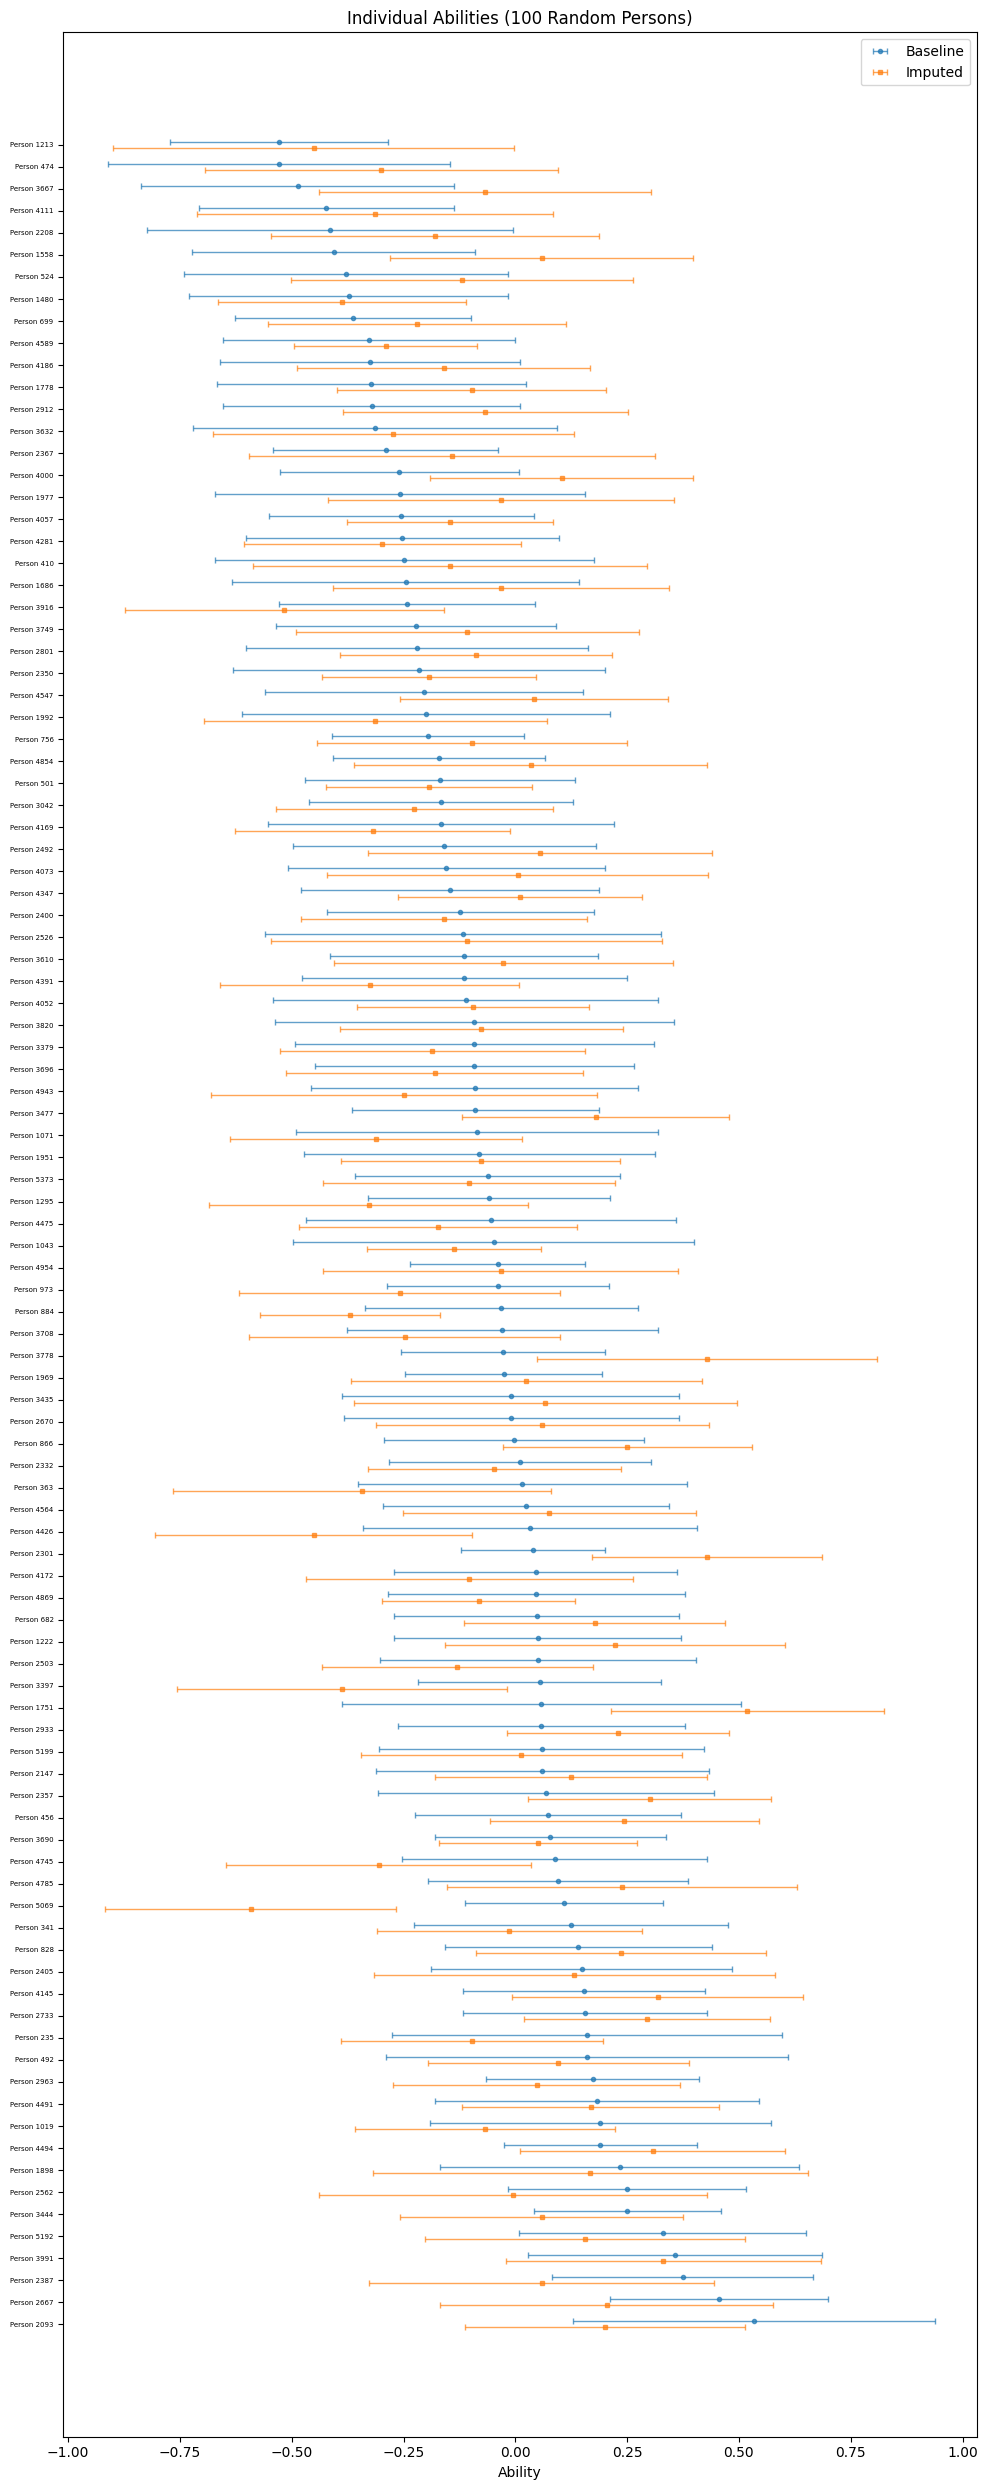

In [16]:
# Forest plot comparing abilities for 100 random individuals
ab_samples_base = np.array(model_baseline.surrogate_sample['abilities'])
ab_samples_imp = np.array(model_imputed.surrogate_sample['abilities'])

ab_samples_base = ab_samples_base.reshape(ab_samples_base.shape[0], -1)
ab_samples_imp = ab_samples_imp.reshape(ab_samples_imp.shape[0], -1)

N = ab_samples_base.shape[1]
rng = np.random.default_rng(42)
idx = rng.choice(N, size=min(100, N), replace=False)
idx = np.sort(idx)

ab_mean_base = ab_samples_base[:, idx].mean(axis=0)
ab_std_base = ab_samples_base[:, idx].std(axis=0)
ab_mean_imp = ab_samples_imp[:, idx].mean(axis=0)
ab_std_imp = ab_samples_imp[:, idx].std(axis=0)

order = np.argsort(ab_mean_base)
ab_mean_base = ab_mean_base[order]
ab_std_base = ab_std_base[order]
ab_mean_imp = ab_mean_imp[order]
ab_std_imp = ab_std_imp[order]

fig, ax = plt.subplots(figsize=(10, 25))
y_pos = np.arange(len(idx))
offset = 0.15

ax.errorbar(ab_mean_base, y_pos - offset, xerr=ab_std_base, fmt='o',
            capsize=2, markersize=3, elinewidth=1, color='tab:blue',
            alpha=0.7, label='Baseline')
ax.errorbar(ab_mean_imp, y_pos + offset, xerr=ab_std_imp, fmt='s',
            capsize=2, markersize=3, elinewidth=1, color='tab:orange',
            alpha=0.7, label='Imputed')

ax.set_yticks(y_pos)
ax.set_yticklabels([f'Person {i}' for i in idx[order]], fontsize=5)
ax.set_xlabel('Ability')
ax.set_title('Individual Abilities (100 Random Persons)')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated fitting a single-dimensional Graded Response Model to the
Taylor Manifest Anxiety Scale (TMA) dataset (50 binary items, K=2). With binary responses,
the GRM reduces to a 2PL IRT model.

Two models were fitted:

1. **Baseline (ignorable missingness)**: Missing responses have their log-likelihood
   contributions zeroed out, assuming the missingness mechanism is ignorable.
2. **Analytic Rao-Blackwellized imputation**: A `MICEBayesianLOO` imputation model
   provides categorical PMFs for missing cells, which are used to analytically
   marginalize over the imputation distribution during model fitting.

The discrimination and ability estimates from both approaches can be compared to assess
the impact of the missingness handling strategy on parameter recovery.